<p class="h1">ECE 447 - Notebook 05</p>
<p class="h1">Linear Models</p>
<p class="h2">Regression: part II</p>

In this section, we cover the following concepts:

- performance evaluation of developed models;
- multi-feature regression;
- concepts of normalization and standardization;
- polynomial regression;
- feature selection process.

# Performance comparison

Let us recall some things from the previous section. 

We have developed a model predicting the sales of a single product based on the investment into radio advertising. Now, we are going to determine how well our model behaves. From the original data points we create two separate sets: one to train a model, and one to test it. 

## Training and testing datasets

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
import warnings; warnings.simplefilter('ignore')

In [62]:
data = pd.read_csv('data/Advertising.csv')
X = data.loc[:,['radio']].values
Y = data['sales'].values.reshape(len(X),1)

In [63]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


We use `scikit-learn` to split the data into training and testing data. 

`test_size=0.3` means \%30 of the data for testing.

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split( X , Y , test_size = 0.3, random_state = 0)

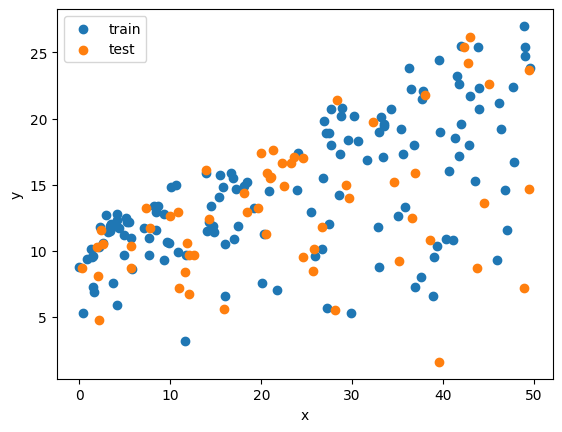

In [65]:
plt.scatter(X_train,Y_train,label='train')
plt.scatter(X_test,Y_test, label='test')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

We use our previously created functions for linear regression.

In [66]:
import sys
sys.path.append('scripts')

In [67]:
import linear_regression as linreg

In [68]:
w, h, w_h = linreg.train(X_train,Y_train, 0.001, 20000)

iter	 Cost 		 Weights
0	20.201759	[[0.63121679 0.51910425]]
2000	11.498557	[[4.57055971 0.35804783]]
4000	9.07941	[[6.73747634 0.2928777 ]]
6000	8.3479055	[[7.92904642 0.25704116]]
8000	8.1267123	[[8.58428125 0.23733494]]
10000	8.0598276	[[8.94458962 0.22649865]]
12000	8.0396029	[[9.14272031 0.22053986]]
14000	8.0334874	[[9.25167079 0.21726317]]
16000	8.0316381	[[9.31158178 0.21546134]]
18000	8.031079	[[9.34452635 0.21447053]]


In [69]:
w

array([[9.36263569],
       [0.21392589]])

Text(0, 0.5, 'training error')

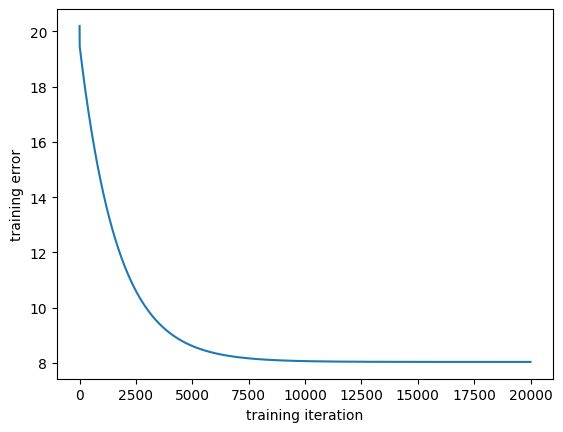

In [70]:
plt.plot(h)
plt.xlabel("training iteration")
plt.ylabel("training error")

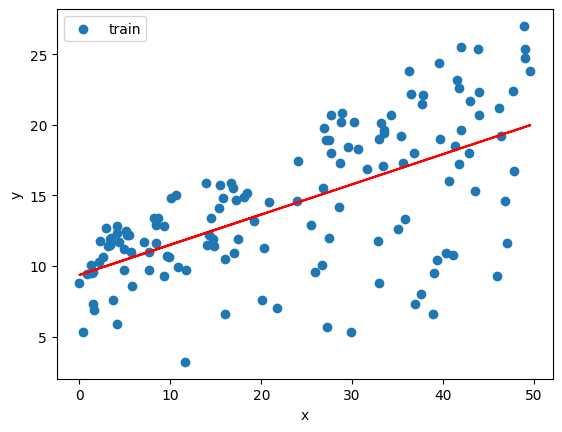

In [71]:
plt.scatter(X_train,Y_train, label="train")
plt.plot(X_train, w[0]+w[1]*X_train, 'r')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

Now we plot out predictions against the testing data. We obtain the following:

In [72]:
bias = np.ones(shape=(len(X_test),1))
Features = np.append(bias, X_test, axis=1)
Y_pred = linreg.predict(Features,w)

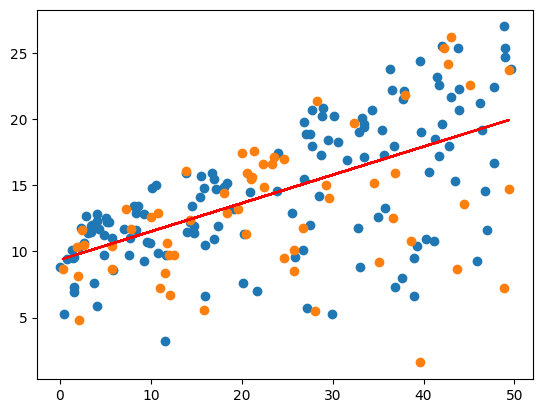

In [73]:
plt.scatter(X_train , Y_train, label="train")
plt.scatter(X_test , Y_test, label="test")
plt.plot(X_test , Y_pred, 'r')

If we compare the cost function values obtained using the training data (`cost_train`) with the testing data (`cost_test`), we can observe a higher cost function value for the testing data. In general, it is normal behaviour. The model is 'learned' based on the training data and 'better suited' to predict if it is exposed to already seen training data than to new, unseen testing data. 

In [74]:
cost_train =  h[-1] # last cost
cost_test = linreg.cost_function(Features, Y_test, w)
cost_train.item(), cost_test.item()

(8.030909925118005, 11.63034771352431)

## Model development using scikit 

Now, let us train the model using `scikit-learn`.

In [75]:
from sklearn import linear_model

In [76]:
sklreg = linear_model.LinearRegression()

In [77]:
sklreg.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
wsk = np.array([sklreg.intercept_,sklreg.coef_[0]])

In [79]:
wsk

array([[9.38477437],
       [0.21326007]])

In [80]:
Y_pred_sk = sklreg.predict(X_test)

A visual comparison between the model developed using our one function, and the model developed using scikit-learn is not easy.  It is difficult to determine which model makes better predictions. 

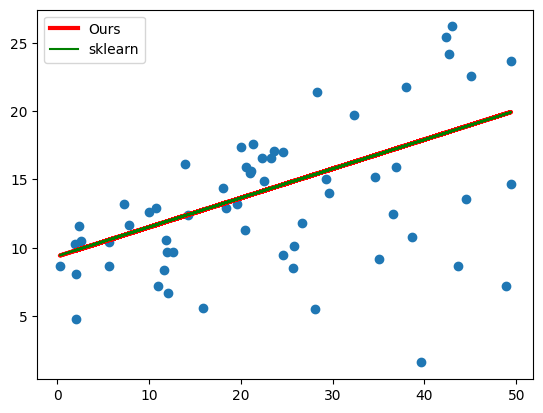

In [81]:
plt.scatter(X_test , Y_test)
plt.plot(X_test , Y_pred, 'r', label='Ours', lw=3)
plt.plot(X_test , Y_pred_sk, 'g', label='sklearn')
plt.legend()

In [82]:
cost_test_sk = linreg.cost_function(Features, Y_test, wsk)
cost_test_sk.item()

11.632214419870207

We use the ***score*** to compare both models.

In [83]:
score_train_sk = sklreg.score(X_train,Y_train)
score_test_sk = sklreg.score(X_test,Y_test)
score_train_sk, score_test_sk

(0.39648649461739305, 0.148565655419297)

Now, we build our own ***score*** function. 

In [84]:
def score(X, Y, w):
    bias = np.ones(shape=(len(X),1))
    Features = np.append(bias, X, axis=1)
    Y_pred = linreg.predict(Features,w)
    u = ((Y - Y_pred) ** 2).sum()
    v = ((Y - Y.mean()) ** 2).sum()
    return 1-u/v

In [85]:
score_train = score(X_train, Y_train, w)
score_test = score(X_test, Y_test, w)
score_train.item(), score_test.item()

(0.3964809837121359, 0.1487022913027819)

In [86]:
import pandas as pd
pd.DataFrame({'Implementation':['ours','scikit-learn'],
              'Train cost':[score_train,score_train_sk],
              'Test cost':[score_test,score_test_sk]})

,Implementation,Train cost,Test cost
0,ours,0.396481,0.148702
1,scikit-learn,0.396486,0.148566


<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Compare the quality of predictions obtained with your linear regression model and the model developed using scikit-learn. The models should predict the sales based on the TV and newspaper investments (data/Advertising.csv).
</div>

# Multi-feature linear regression

## Model development (two features)

So far, we have developed a regression model based on data with only one feature. However in most cases, we have data that has more than one feature as dependent variables. 

In these cases, we use the same method for computing a linear regression, but change the way  the hypothesis is expressed.
Now, the hypotthesis is represented as a linear combination:

$$
f_\theta(X) = \theta_0 + \theta_1x_1+\theta_2x_2+\theta_3x_3+...
$$

The same predictor function (matrix version), as defined previously, can be used to represent the multi-feature hypothesis. 

$$
\theta = \left[
\begin{matrix}
\theta_0 & \theta_1 & ... & \theta_p 
\end{matrix}
\right]^T
$$

$$
X = \left[ 
\begin{matrix}
 1 & x_{1_1} & ... & x_{p_1} \\
 1 & x_{1_2} & ... & x_{p_2} \\
 \vdots & \vdots & & \vdots \\
 1 & x_{1_n} & ... & x_{p_n} \\
\end{matrix}
\right]
$$

In [54]:
def predictor(Features, Weights):
    return Features @ Weights # dot product

Let us go back to the problem of predicting how investments in radio and TV advertisments affect sales:

$$
f_\theta(radio,TV) = \theta_0 + \theta_1 radio + \theta_2 TV
$$

In [94]:
data = pd.read_csv('data/Advertising.csv')
X = data.loc[:,['radio','TV']].values
Y = data['sales'].values.reshape(len(X),1)

print("X shape", X.shape)
print("Y shape", Y.shape)

X shape (200, 2)
Y shape (200, 1)


In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split( X , Y , test_size = 0.3, random_state = 0)

print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("Y_train", Y_train.shape)
print("Y_test", Y_test.shape)

X_train (140, 2)
X_test (60, 2)
Y_train (140, 1)
Y_test (60, 1)


The plot of the training and testing data points looks like this:

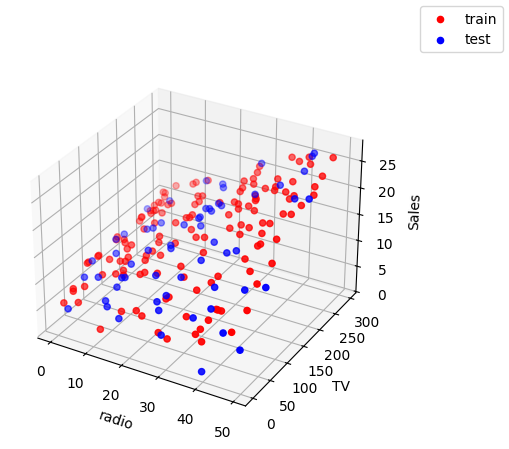

In [113]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# ax.view_init(elev=10., azim=25)
ax.scatter(X_train[:,0], X_train[:,1], Y_train[:,0],c='r',label='train')
ax.scatter(X_test[:,0], X_test[:,1], Y_test[:,0],c='b',label='test')
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')
fig.legend()

We use our linear regression implementation. 

In [114]:
import linear_regression as linreg

In [115]:
%time w, h, w_h = linreg.train(X_train,Y_train, 0.00001, 200000)

iter	 Cost 		 Weights
0	610.51631	[[0.57459395 0.53855847 0.21214958]]
20000	1.6440614	[[0.64126106 0.23439031 0.05136388]]
40000	1.6199314	[[0.71071984 0.23336785 0.0511374 ]]
60000	1.5972564	[[0.77805199 0.2323767  0.05091785]]
80000	1.5759485	[[0.84332264 0.2314159  0.05070502]]
100000	1.5559255	[[0.9065949  0.23048451 0.05049871]]
120000	1.5371098	[[0.96792995 0.22958164 0.05029871]]
140000	1.5194286	[[1.02738711 0.22870641 0.05010484]]
160000	1.5028135	[[1.08502386 0.22785798 0.0499169 ]]
180000	1.4872003	[[1.14089595 0.22703552 0.04973472]]
CPU times: user 1.03 s, sys: 147 ms, total: 1.18 s
Wall time: 1.06 s


Text(0, 0.5, 'training loss')

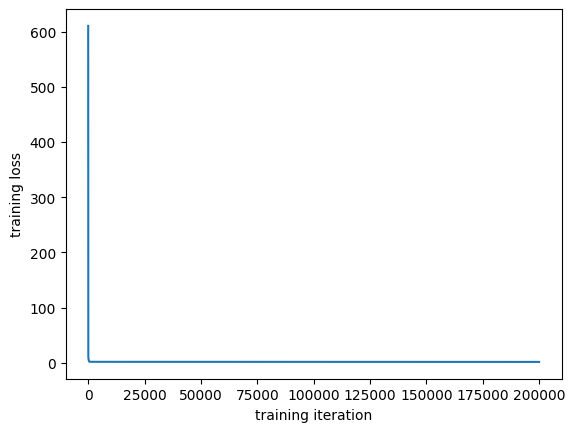

In [116]:
plt.plot(h)
plt.xlabel("training iteration")
plt.ylabel("training loss")

In the plot below, we can observe the hyperplane generated using the parameters from our trained model.

Text(0.5, 0, 'Sales')

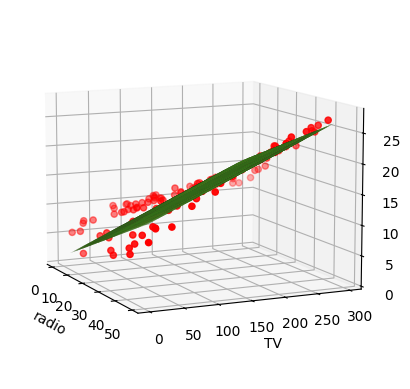

In [119]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10., azim=-25) # -25
x1,x2 = np.meshgrid(X_train[:,0], X_train[:,1])
zp = w[0] + w[1]*x1 + w[2]*x2
ax.plot_surface(x1,x2,zp, color=[0.4,0.7,0.2,0.05])
ax.scatter(X_train[:,0], X_train[:,1], Y_train[:,0],c='r')
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')

## Normalization

As we observed in the training process, it have taken more time and required a smaller learning rate. To speed up the gradiant descent in multi-feature regression, we could use data scaling methods. Two of these methods are *normalization* and *standardization*

**Normalization** (or min-max scaling) is defined as:

$$
X' = \frac{X-\min(X)}{\max(X)-\min(X)}
$$

where each value of $X'$ in in the range $[0,1]$

In [134]:
def normalization(Features):
    """
    Take a set of features return normalize values using
    (x -xmin) / (xmax – xmin) of each feature
    """
    fmin = np.min(Features,axis=0)
    print("Features", Features.shape, "fmin", fmin.shape)
    fmax = np.max(Features,axis=0)
    Features_norm = (Features - fmin)/(fmax-fmin)
    return Features_norm

In [135]:
X_train

array([[  2.9, 265.2],
       [  3.5, 197.6],
       [  5.4, 218.5],
       [ 23.9, 147.3],
       [ 39.7, 171.3],
       [ 33.5, 217.7],
       [ 28.8, 262.7],
       [ 36.8, 163.5],
       [  9.6, 100.4],
       [ 27.5,  76.3],
       [ 43.9, 184.9],
       [  4.9, 134.3],
       [ 28.9, 273.7],
       [ 36.3, 296.4],
       [ 14.8,  96.2],
       [ 47.8, 109.8],
       [ 26.9, 255.4],
       [ 32.9, 204.1],
       [ 16.7, 240.1],
       [ 35.4, 193.7],
       [ 28.7, 191.1],
       [  9.9,  89.7],
       [ 25.9,  43. ],
       [  3.7,  38.2],
       [  0.4,  13.1],
       [ 15.5, 239.3],
       [ 45.9,  17.2],
       [ 29.5, 210.7],
       [ 39. ,  25.6],
       [  9.3, 177. ],
       [  8.4, 206.9],
       [  5.8,  66.1],
       [ 35.6, 149.7],
       [  5.7, 129.4],
       [  4.9,  94.2],
       [  2.3, 276.7],
       [ 48.9, 276.9],
       [ 38.9,   7.8],
       [ 36.5, 250.9],
       [ 15.4, 175.7],
       [ 36.9,  11.7],
       [ 10.8,  75.5],
       [  3.1, 199.8],
       [ 37

In [136]:
X_train_norm = normalization(X_train)

Features (140, 2) fmin (2,)


In [137]:
X_train_norm

array([[0.05846774, 0.89326035],
       [0.07056452, 0.66199111],
       [0.10887097, 0.73349299],
       [0.48185484, 0.48990763],
       [0.80040323, 0.57201505],
       [0.67540323, 0.73075607],
       [0.58064516, 0.88470749],
       [0.74193548, 0.54533014],
       [0.19354839, 0.32945604],
       [0.55443548, 0.2470065 ],
       [0.88508065, 0.61854259],
       [0.09879032, 0.44543277],
       [0.58266129, 0.92234006],
       [0.73185484, 1.        ],
       [0.2983871 , 0.31508724],
       [0.96370968, 0.36161478],
       [0.54233871, 0.85973315],
       [0.66330645, 0.68422853],
       [0.33669355, 0.80738967],
       [0.71370968, 0.64864865],
       [0.57862903, 0.63975368],
       [0.19959677, 0.29284981],
       [0.52217742, 0.13308245],
       [0.07459677, 0.11666096],
       [0.00806452, 0.03079028],
       [0.3125    , 0.80465275],
       [0.92540323, 0.04481697],
       [0.59475806, 0.70680807],
       [0.78629032, 0.07355457],
       [0.1875    , 0.59151557],
       [0.

After normaliztion, training of the model is faster.

In [138]:
%time w_n, h_n, w_h_n = linreg.train(X_train_norm,Y_train, 0.001, 30000)

iter	 Cost 		 Weights
0	110.02377	[[0.17214908 0.10489158 0.37065736]]
3000	3.8282949	[[8.45553786 5.70945621 6.63011973]]
6000	3.0370312	[[7.6497645  6.49358978 7.67088598]]
9000	2.4940159	[[6.89596518 7.09808227 8.50217559]]
12000	2.1156074	[[6.26635242 7.59539071 9.20106988]]
15000	1.8518403	[[5.74111679 8.00523297 9.78872585]]
18000	1.6679431	[[ 5.30291167  8.34328147 10.28260423]]
21000	1.5397069	[[ 4.93727716  8.62233643 10.6974789 ]]
24000	1.45027	[[ 4.63216454  8.85286834 11.04584075]]
27000	1.3878847	[[ 4.37753236  9.04345197 11.33823996]]
CPU times: user 200 ms, sys: 83.1 ms, total: 283 ms
Wall time: 212 ms


Text(0, 0.5, 'training loss')

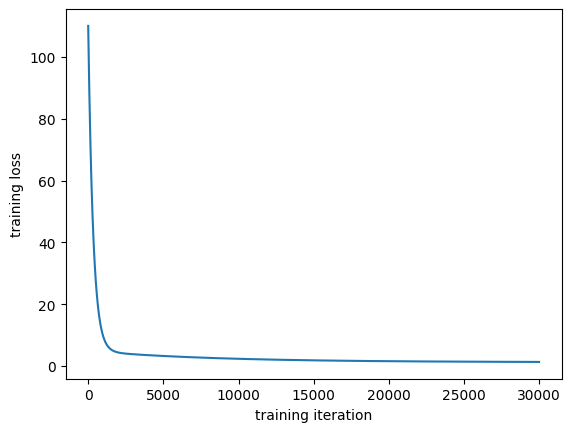

In [139]:
plt.plot(h_n)
plt.xlabel("training iteration")
plt.ylabel("training loss")

Text(0.5, 0.92, 'With normalization')

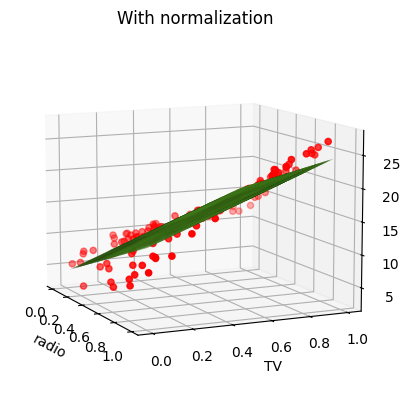

In [141]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10., azim=-25)
x1,x2 = np.meshgrid(X_train_norm[:,0], X_train_norm[:,1])
zp = w_n[0] + w_n[1]*x1 + w_n[2]*x2
ax.plot_surface(x1,x2,zp, color=[0.4,0.7,0.2,0.05])
ax.scatter(X_train_norm[:,0], X_train_norm[:,1], Y_train[:,0],c='r')
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')
ax.set_title("With normalization")

## Standardization 

Another scaling method - **standardization** - modifies a feature in a way so that it has zero as its mean value, and zero as its standard deviation. This method is commonly used for logistic regression, suport vector machine and neural networks.

$$
X' = \frac{X-\mu(X)}{\sigma(X)}
$$

where $\mu(X')=0$ and $\sigma(X')=1$ ($\mu$: mean, $\sigma$: standard deviation)

In [142]:
def standardization(Features):
    """
    Take a set of features return normalize values using
    the mean and standard deviation of each feature
    """
    mean=np.mean(Features,axis=0)
    std=np.std(Features,axis=0)
    Features_zss = (Features - mean)/std
    return Features_zss

In [143]:
X_train_std = standardization(X_train)

In [144]:
%time w_s, h_s, w_h_s = linreg.train(X_train_std, Y_train, 0.001, 30000)

iter	 Cost 		 Weights
0	101.05856	[[0.69959787 0.78740552 0.97905099]]
3000	1.4863576	[[13.67683605  2.96776077  3.56999456]]
6000	1.2444644	[[14.32196562  3.05774354  3.68374112]]
9000	1.2438742	[[14.35403656  3.06140535  3.68877832]]
12000	1.2438727	[[14.35563088  3.06155127  3.68900384]]
15000	1.2438727	[[14.35571014  3.0615569   3.68901408]]
18000	1.2438727	[[14.35571408  3.0615571   3.68901455]]
21000	1.2438727	[[14.35571428  3.06155711  3.68901457]]
24000	1.2438727	[[14.35571429  3.06155711  3.68901457]]
27000	1.2438727	[[14.35571429  3.06155711  3.68901457]]
CPU times: user 199 ms, sys: 82.5 ms, total: 281 ms
Wall time: 211 ms


Text(0, 0.5, 'training loss')

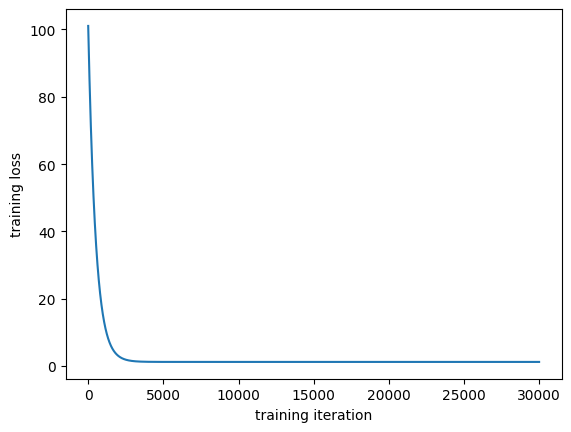

In [145]:
plt.plot(h_s)
plt.xlabel("training iteration")
plt.ylabel("training loss")

Text(0.5, 0.92, 'With standarization')

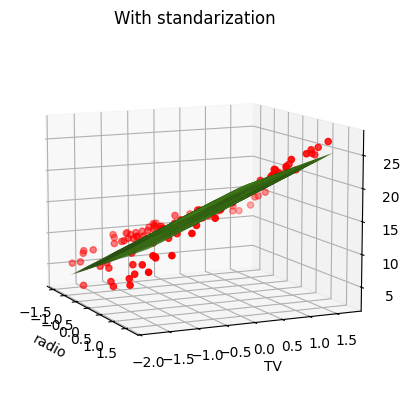

In [149]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10., azim=-25) #-25
x1,x2 = np.meshgrid(X_train_std[:,0], X_train_std[:,1])
zp = w_s[0] + w_s[1]*x1 + w_s[2]*x2
ax.plot_surface(x1,x2,zp, color=[0.4,0.7,0.2,0.05])
ax.scatter(X_train_std[:,0], X_train_std[:,1], Y_train[:,0],c='r')
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')
ax.set_title("With standarization")

## Model development with scikit-learn

Let us create a model using `scikit-learn`.

In [150]:
sklreg = linear_model.LinearRegression()

To perform data normalization with `scikit-learn`, we use `MinMaxScaler`.

In [153]:
# With normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

scaler

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [155]:
print(X_train_norm)

[[0.05846774 0.89326035]
 [0.07056452 0.66199111]
 [0.10887097 0.73349299]
 [0.48185484 0.48990763]
 [0.80040323 0.57201505]
 [0.67540323 0.73075607]
 [0.58064516 0.88470749]
 [0.74193548 0.54533014]
 [0.19354839 0.32945604]
 [0.55443548 0.2470065 ]
 [0.88508065 0.61854259]
 [0.09879032 0.44543277]
 [0.58266129 0.92234006]
 [0.73185484 1.        ]
 [0.2983871  0.31508724]
 [0.96370968 0.36161478]
 [0.54233871 0.85973315]
 [0.66330645 0.68422853]
 [0.33669355 0.80738967]
 [0.71370968 0.64864865]
 [0.57862903 0.63975368]
 [0.19959677 0.29284981]
 [0.52217742 0.13308245]
 [0.07459677 0.11666096]
 [0.00806452 0.03079028]
 [0.3125     0.80465275]
 [0.92540323 0.04481697]
 [0.59475806 0.70680807]
 [0.78629032 0.07355457]
 [0.1875     0.59151557]
 [0.16935484 0.69380773]
 [0.11693548 0.21211085]
 [0.71774194 0.49811837]
 [0.11491935 0.42866918]
 [0.09879032 0.30824495]
 [0.04637097 0.93260349]
 [0.9858871  0.93328772]
 [0.78427419 0.01265823]
 [0.7358871  0.84433801]
 [0.31048387 0.58706808]


In [156]:
sklreg.fit(X_train_norm,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [157]:
wsk = [sklreg.intercept_[0],sklreg.coef_[0][0],sklreg.coef_[0][1]]

In [160]:
wsk

[np.float64(3.090158407657656),
 np.float64(9.969364948633592),
 np.float64(12.851412736927635)]

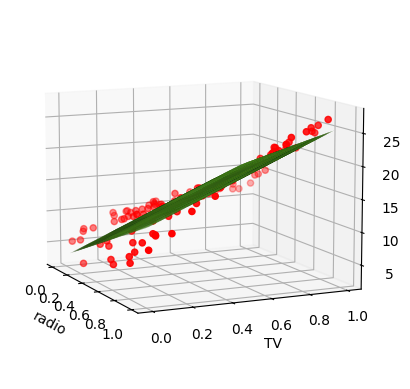

In [162]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10., azim=-25)
x1,x2 = np.meshgrid(X_train_norm[:,0], X_train_norm[:,1])
zp = wsk[0] + wsk[1]*x1 + wsk[2]*x2
ax.plot_surface(x1,x2,zp, color=[0.4,0.7,0.2,0.05])
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')
ax.scatter(X_train_norm[:,0], X_train_norm[:,1], Y_train[:,0],c='r')

To do data standardization, we need to import and create an instance of `StandardScaler` from `sklearn.preprocessing` and transform the features.

In [166]:
# Using Standardization
from sklearn.preprocessing import StandardScaler
#X_train_scaled = StandardScaler().fit_transform(X_train)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [164]:
sklreg.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [165]:
wsk = [sklreg.intercept_[0],sklreg.coef_[0][0],sklreg.coef_[0][1]]

In [57]:
wsk

[14.355714285714285, 3.061557109904863, 3.6890145735048914]

Text(0.5, 0, 'Sales')

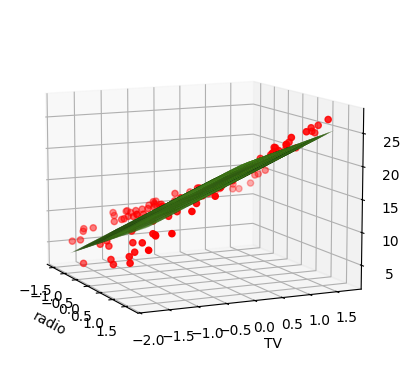

In [168]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10., azim=-25)
x1,x2 = np.meshgrid(X_train_scaled[:,0], X_train_scaled[:,1])
zp = wsk[0] + wsk[1]*x1 + wsk[2]*x2
ax.plot_surface(x1,x2,zp, color=[0.4,0.7,0.2,0.05])
ax.scatter(X_train_scaled[:,0], X_train_scaled[:,1], Y_train[:,0],c='r')
ax.set_xlabel('radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')

In [169]:
bias = np.ones(shape=(len(X_test_scaled),1))
Features = np.append(bias, X_test_scaled, axis=1)
Y_pred = linreg.predict(Features,wsk)

In [170]:
Y_pred_sk = sklreg.predict(X_test_scaled)

## Performance comparison

Let us compare the performance of all obtained results using the *score*.

In [172]:
import pandas as pd
pd.DataFrame({'':['Without normalization','With normalization','With standarization','scikit-learn'],
              'Train score':[score(X_train, Y_train, w),
                             score(X_train_norm, Y_train, w_n),
                             score(X_train_std, Y_train, w_s),
                             sklreg.score(X_train_scaled,Y_train)],
              'Test score':[score(X_test, Y_test, w),
                            score(normalization(X_test), Y_test, w_n),
                            score(standardization(X_test), Y_test, w_s),
                            sklreg.score(X_test_scaled,Y_test)]})

Features (60, 2) fmin (2,)


,,Train score,Test score
0,Without normalization,0.889340,0.847885
1,With normalization,0.898971,0.850399
2,With standarization,0.906524,0.797501
3,scikit-learn,0.906524,0.865655


<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Compare the quality of predictions obtained using our linear regression implementation and the one obtained using `scikit-learn`, by predicting the sales using pair-wise combinations of radio, TV and newspaper investments, i.e., radio and newspaper, TV and newspaper, TV and newspaper. Compare how the performance changes if normalization and standardization are used.

## Model development (three features)

Now we want to know how radio, TV and newspaper all together affect the sales. In this case, our hypothesis function changes to the following:

$$
h_\theta(radio,TV,newspaper) = \theta_0 + \theta_1 radio + \theta_2 TV + \theta_3 newspaper
$$

In [173]:
data = pd.read_csv('data/Advertising.csv')
X = data.loc[:,['radio','TV','newspaper']].values
Y = data['sales'].values.reshape(len(X),1)

Again, we create training and testing sets from the given data points.

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split( X , Y , test_size = 0.2, random_state = 0)

Text(0.5, 0, 'newspaper')

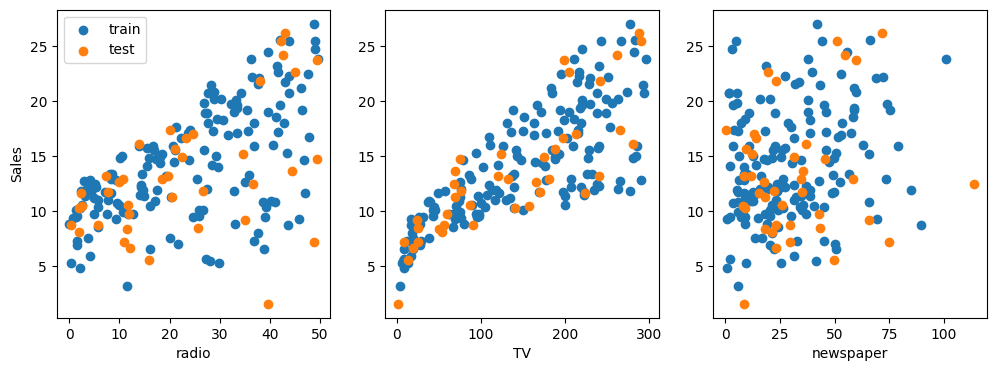

In [176]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(X_train[:,0],Y_train, label='train')
plt.scatter(X_test[:,0],Y_test, label='test')
plt.ylabel('Sales')
plt.xlabel('radio')
plt.legend()
plt.subplot(1,3,2)
plt.scatter(X_train[:,1],Y_train)
plt.scatter(X_test[:,1],Y_test)
plt.xlabel('TV')
plt.subplot(1,3,3)
plt.scatter(X_train[:,2],Y_train)
plt.scatter(X_test[:,2],Y_test)
plt.xlabel('newspaper')

In [177]:
sklreg = linear_model.LinearRegression()

In [178]:
sklreg.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [179]:
wsk = [sklreg.intercept_[0],sklreg.coef_[0][0],sklreg.coef_[0][1],sklreg.coef_[0][2]]

In [180]:
wsk

[np.float64(2.9948930304953247),
 np.float64(0.19649703415540504),
 np.float64(0.04458402011996429),
 np.float64(-0.002781463981925935)]

In [181]:
score_train, score_test = sklreg.score(X_train,Y_train),sklreg.score(X_test,Y_test)
score_train, score_test

(0.9067114990146382, 0.8601145185017868)

The results obtained after normalization are as follows:

In [182]:
# Using normalization
sklreg_norm = linear_model.LinearRegression()
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
sklreg_norm.fit(X_train_norm,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [183]:
score_train_norm, score_test_norm = sklreg_norm.score(X_train_norm,Y_train),sklreg_norm.score(X_test_norm,Y_test)
score_train_norm, score_test_norm

(0.9067114990146383, 0.8601145185017869)

The results obtained after standarization are as follows:

In [184]:
# Using Standardization
from sklearn.preprocessing import StandardScaler
X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

In [ ]:
sklreg.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
score_train_std, score_test_std = sklreg.score(X_train_scaled,Y_train),sklreg.score(X_test_scaled,Y_test)
score_train_std, score_test_std

(0.9067114990146383, 0.8281217233452882)

The results obtained after both normalization and standardization are used:

In [75]:
sklreg_norm.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
score_train_norm_std, score_test_norm_std = sklreg_norm.score(X_train_scaled,Y_train),sklreg_norm.score(X_test_scaled,Y_test)
score_train_norm_std, score_test_norm_std

(0.9067114990146383, 0.8281217233452882)

When we compare all the results, we have:

In [77]:
pd.DataFrame({'':['Original input','With normalization','With standarization','With normalization and standardization'],
              'Train score':[score_train,
                             score_train_norm,
                             score_train_std,
                             score_train_norm_std
                            ],
              'Test score':[score_test,
                             score_test_norm,
                             score_test_std,
                             score_test_norm_std
                           ] } )

,,Train score,Test score
0,Original input,0.906711,0.860115
1,With normalization,0.906711,0.860115
2,With standarization,0.906711,0.828122
3,With normalization and standardization,0.906711,0.828122


# Polynomial regression

**Polynomial regression** is a special case of linear regression. 
A multivariate regression of one variable ($x$), with a polynomial degree of 2 is:

$$
f_\theta(x) = \theta_0+\theta_1x+\theta_2x^2
$$

Now the hypothesis can be written as follows:

$$
f_\theta(x) = \theta_0+\theta_1x'_1+\theta_2x'_2
$$

This means that the polynomial regression can be treated as a normal linear regression by expanding the feature base. For example, if we have the following feature vector:

$$
X = \left[ 
\begin{matrix}
3\\
5\\
4\\
2
\end{matrix}
\right]
$$

We can expand the feature set ($X$) by addding/creating a second column with the values of the features equal to the original features, to the power of two:

$$
X' = \left[ 
\begin{matrix}
3 & 9\\
5 & 25\\
4 & 16\\
2 & 4
\end{matrix}
\right]
$$

Now we can use our linear regression process.


For multi-features and polynomial regression, the idea is the same. In the case of two features and quadratic polynomial regression, we have:

$$
f_\theta(x) = \theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_1^2+\theta_4x_1x_2+\theta_5x_2^2,
$$

which can be rewrritten in terms of expanded features:

$$
f_\theta(x) = \theta_0+\theta_1x'_1+\theta_2x'_2+\theta_3x'_3+\theta_4x'_4+\theta_5x'_5
$$



In [190]:
# Simple function to generate points along a sine line
def gen_poly_samples(n, a=0.7, s=0.1, b=5):
    """
    n: Number of point to generate
    a: lines slope
    s: spread distance
    b: intercept with y axis
    """
    X = np.sort(np.random.rand(n))
    Y = np.sin(a * np.pi * X) + b + np.random.randn(n) * s
    return X.reshape(n,1),Y.reshape(n,1)

In [191]:
X_train,Y_train = gen_poly_samples(50)
X_test,Y_test = gen_poly_samples(10)

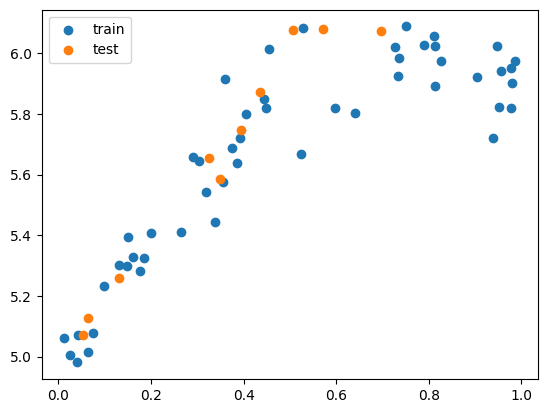

In [192]:
plt.scatter(X_train, Y_train, label='train')
plt.scatter(X_test, Y_test, label='test')
plt.legend()

Given the previous set of data points, we create a linear regression model:

In [193]:
sklreg = linear_model.LinearRegression()
sklreg.fit(X_train,Y_train)
Y_pred = sklreg.predict(X_train)

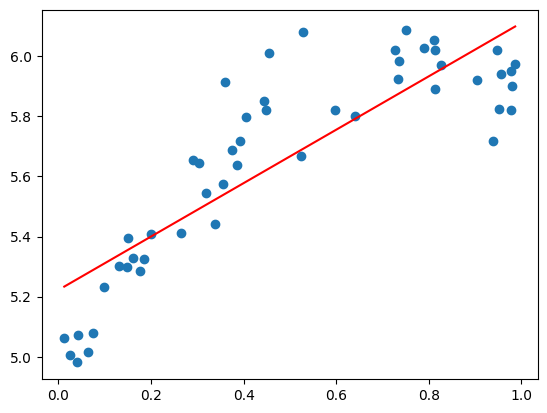

In [194]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,Y_pred,'r')

In [195]:
sklreg.score(X_train,Y_train),sklreg.score(X_test,Y_test)

(0.731291639097945, 0.6140036905609813)

In [196]:
X_train

array([[0.01253601],
       [0.02489138],
       [0.03995796],
       [0.04162711],
       [0.06294322],
       [0.07467117],
       [0.09868899],
       [0.13146888],
       [0.14910511],
       [0.14995712],
       [0.16003834],
       [0.17560583],
       [0.18558426],
       [0.19908223],
       [0.2644375 ],
       [0.29028203],
       [0.30285205],
       [0.31866176],
       [0.33723609],
       [0.3545986 ],
       [0.35937995],
       [0.37525119],
       [0.38474392],
       [0.39123303],
       [0.40630473],
       [0.4444103 ],
       [0.44807147],
       [0.45559608],
       [0.52482737],
       [0.52905874],
       [0.59720857],
       [0.64071055],
       [0.72695463],
       [0.7343345 ],
       [0.73525301],
       [0.75182985],
       [0.79011469],
       [0.81048406],
       [0.81460234],
       [0.81471188],
       [0.82689786],
       [0.90432775],
       [0.93985182],
       [0.94772605],
       [0.95272442],
       [0.95710761],
       [0.9772151 ],
       [0.978

Now, using polynomial regression to create a second model:

In [197]:
from sklearn.preprocessing import PolynomialFeatures

In [198]:
poly_features = PolynomialFeatures(degree=2)

In [199]:
X_train_poly = poly_features.fit_transform(X_train)

In [200]:
X_train_poly

array([[1.00000000e+00, 1.25360136e-02, 1.57151636e-04],
       [1.00000000e+00, 2.48913799e-02, 6.19580793e-04],
       [1.00000000e+00, 3.99579631e-02, 1.59663882e-03],
       [1.00000000e+00, 4.16271146e-02, 1.73281667e-03],
       [1.00000000e+00, 6.29432248e-02, 3.96184955e-03],
       [1.00000000e+00, 7.46711658e-02, 5.57578301e-03],
       [1.00000000e+00, 9.86889901e-02, 9.73951676e-03],
       [1.00000000e+00, 1.31468876e-01, 1.72840653e-02],
       [1.00000000e+00, 1.49105115e-01, 2.22323353e-02],
       [1.00000000e+00, 1.49957124e-01, 2.24871390e-02],
       [1.00000000e+00, 1.60038343e-01, 2.56122711e-02],
       [1.00000000e+00, 1.75605833e-01, 3.08374085e-02],
       [1.00000000e+00, 1.85584261e-01, 3.44415179e-02],
       [1.00000000e+00, 1.99082232e-01, 3.96337351e-02],
       [1.00000000e+00, 2.64437495e-01, 6.99271889e-02],
       [1.00000000e+00, 2.90282034e-01, 8.42636592e-02],
       [1.00000000e+00, 3.02852051e-01, 9.17193650e-02],
       [1.00000000e+00, 3.18661

In [201]:
sklreg_poly = linear_model.LinearRegression()
sklreg_poly.fit(X_train_poly,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [202]:
Xl = np.linspace(0, 1, 100).reshape(100,1)

In [203]:
Xl_poly = poly_features.fit_transform(Xl)

In [204]:
Y_pred = sklreg_poly.predict(Xl_poly)

Text(0, 0.5, 'y')

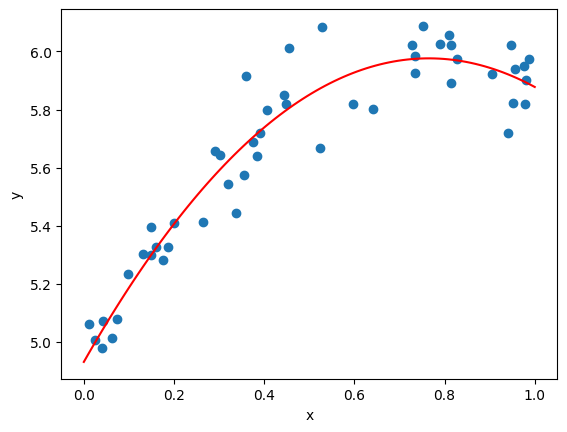

In [206]:
plt.scatter(X_train,Y_train)
plt.plot(Xl,Y_pred,'r')
plt.xlabel("x")
plt.ylabel("y")

In [207]:
sklreg_poly.score(X_train_poly,Y_train),sklreg_poly.score(poly_features.fit_transform(X_test),Y_test)

(0.9163303214432188, 0.9239718205853121)

As we can see, the polynomial regression produced better predictions than did the linear model. 

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Change the polynomial degree (e.g., 3,5,10) and compare the score results for training and testing data sets.

## Polynomial Degree

From the exercise, we found that using different polynomial degrees produces improvements or reductions in the model performance. To determine the right polynomial degree to use, we need to test the different possibilities and compare them. We will use Mean Square Error to measure the performance, considering the training and testing data.

In [208]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

This first version uses cross-validation (k-fold cross-validation) over the data points

In [209]:
def compute_mse_cv(X, Y, n_degree=6):
    mse = []
    std = []
    for degree in range(1,n_degree):
        poly_features = PolynomialFeatures(degree=degree)
        sklreg = linear_model.LinearRegression()
        pipeline = Pipeline([("polynomial_features", poly_features),
                             ("linear_regression", sklreg)])
        pipeline.fit(X, Y) 

        # Evaluate the models using crossvalidation
        scores = cross_val_score(pipeline, X, Y,
                                 scoring="neg_mean_squared_error", 
                                 cv=10, error_score=np.nan)
        
        mse.append(-scores.mean())
        std.append(scores.std())       
    return mse,std

In [210]:
X_train,Y_train = gen_poly_samples(30)

In [211]:
mse,std = compute_mse_cv(X_train,Y_train)

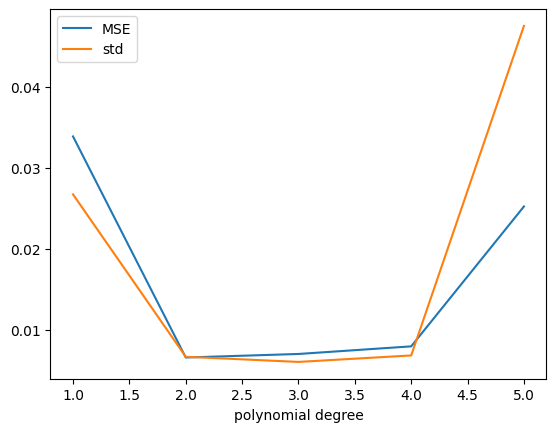

In [214]:
plt.plot(range(1,len(mse)+1),mse, label='MSE')
plt.plot(range(1,len(std)+1),std, label='std')
plt.xlabel("polynomial degree")
plt.legend()

This second version uses separated sets for training and testing to compare how the performance changes for training data vs testing data

In [218]:
def compute_mse(X_train, Y_train, X_test, Y_test, n_degree=11):
    train_mse = []
    test_mse = []
    for degree in range(1,n_degree):
        poly_features = PolynomialFeatures(degree=degree)
        sklreg = linear_model.LinearRegression()
        pipeline = Pipeline([("polynomial_features", poly_features),
                             ("linear_regression", sklreg)])
        pipeline.fit(X_train, Y_train)
        Y_train_pred = pipeline.predict(X_train)
        Y_test_pred = pipeline.predict(X_test)

        train_mse.append(mean_squared_error(Y_train, Y_train_pred))
        test_mse.append(mean_squared_error(Y_test, Y_test_pred))
    return train_mse,test_mse

In [219]:
X_test,Y_test = gen_poly_samples(40)
train_mse,test_mse = compute_mse(X_train,Y_train,X_test,Y_test)

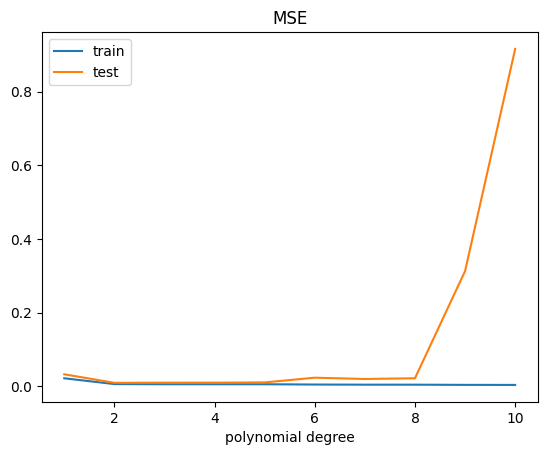

In [221]:
plt.plot(range(1,len(train_mse)+1),train_mse, label='train')
plt.plot(range(1,len(test_mse)+1),test_mse, label='test')
plt.title('MSE')
plt.xlabel("polynomial degree")
plt.legend()

In [222]:
test_mse

[0.03243450625647619,
 0.009229426774778008,
 0.009665307598870848,
 0.009685152032428335,
 0.010414829820597202,
 0.023161374674951905,
 0.019688621376157216,
 0.021650343306592046,
 0.31278355234643207,
 0.9164288097329047]

In [223]:
print("Best degree: ",np.argmin(test_mse)+1)

Best degree:  2


To understand this behaviour, let us plot the predicted curves.

In [224]:
def plot_models(X,Y,X_test, Y_test, degrees):
    for i,degree in enumerate(degrees):
        ax = plt.subplot(1, len(degrees), i + 1)
        poly_features = PolynomialFeatures(degree=degree)
        sklreg = linear_model.LinearRegression()
        pipeline = Pipeline([("polynomial_features", poly_features),
                             ("linear_regression", sklreg)])
        pipeline.fit(X,Y)
        Y_pred = pipeline.predict(X)
        plt.plot(X_test, pipeline.predict(X_test), label="Model")
        plt.scatter(X, Y, edgecolor='b', s=20, label="Samples")
        plt.scatter(X_test, Y_test, edgecolor='r',s=15, label="Test")
        plt.xlabel("x")
        plt.title("Degree {}".format(degree))
        plt.legend(loc="best")

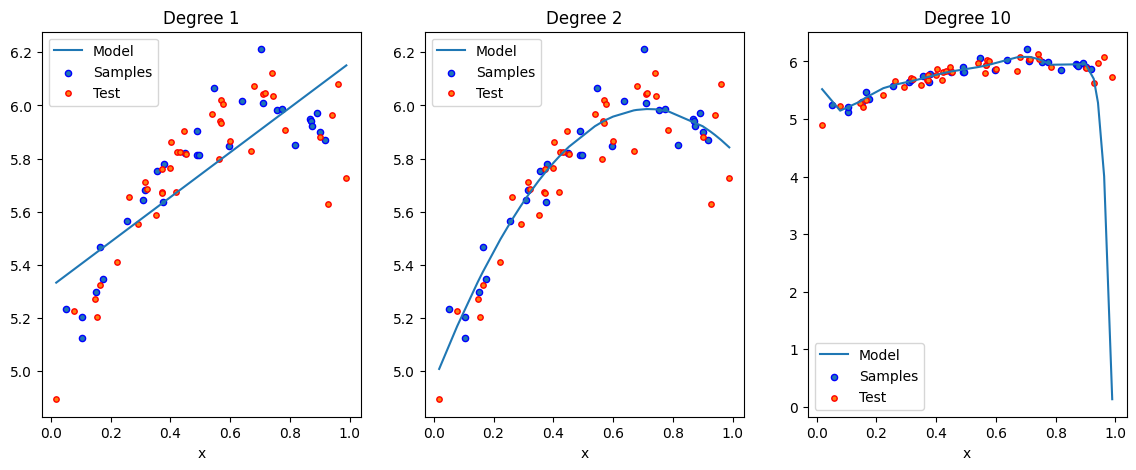

In [225]:
plt.figure(figsize=(14, 5))
plot_models(X_train,Y_train,X_test,Y_test,[1,2,10])

The previous results show the problems of *underfitting* and *overfitting* that can be presented using linear regression with polynomial features to approximate nonlinear functions.

We call **underfitting** when the model is not sufficient to fit the training data (e.g., degree=1). On the other hand, when the model fits the training data too much, we call it **overfitting**.

# Feature selection

An important aspect that should be considered when we have multiple features is that not all the features contribute to the model's performance in the same way. Some features are more important than others. To determine which features are most significant, we can use the measures, F-test and p-value.
        
**F-test** estimates the degree of linear dependency between two random variables when comparing their variances. (See [The F-test for Linear Regression](http://facweb.cs.depaul.edu/sjost/csc423/documents/f-test-reg.htm) for an explanation how to calculate it.)

**p-value** is another measure that helps us determine the significance of each feature. It is used to validate or reject the **null hypothesis**. The null hypothesis ($H_0$) assumes that there is **no relationship** between a given input feature and the output. In the context of our model, it assumes that $\theta_i=0$ for $0 \leq i \le n$, where $n$ is the number of parameters. The meaning of the obtained p-values is as follows:

- a small p-value (typically < 0.05) indicates strong evidence against the null hypothesis. The null hypothesis is rejected;

- a large p-value (> 0.05) indicates weak evidence against the null hypothesis. The null hypothesis is NOT rejected.

p-value represents the probability that the coefficient is actually zero. (For more information about [p-value](https://en. .wikipedia.org/wiki/P-value).) 

`scikit-learn` provides functions to compute F-test and p-value, as well asa  function to remove the features with low significance.

In [ ]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [227]:
from sklearn.feature_selection import f_regression

In [228]:
data = pd.read_csv('data/Advertising.csv')
X = data.loc[:,['radio','TV','newspaper']].values
Y = data['sales'].values

In [229]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [230]:
F_test,p_value=f_regression(X_poly,Y)
pd.DataFrame({'feature':poly_features.get_feature_names_out(),
              'F_test':F_test,'p_value':p_value})

,feature,F_test,p_value
0,x0,98.421588,4.354966e-19
1,x1,312.144994,1.467390e-42
2,x2,10.887299,1.148196e-03
3,x0^2,91.221485,5.094036e-18
4,x0 x1,2597.227925,8.778003e-116
5,x0 x2,41.409935,9.099688e-10
6,x1^2,233.448111,2.491900e-35
7,x1 x2,122.691160,1.680741e-22
8,x2^2,9.646788,2.175199e-03


Using `SelectKBest`, we can reduce a number of features based on their significance.

In [231]:
from sklearn.feature_selection import SelectKBest

In [232]:
X_best = SelectKBest(f_regression,k=3).fit_transform(X_poly, Y)

In [233]:
selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(X_poly, Y)
selected_features_mask = selector.get_support()
selected_features_mask

array([False,  True, False, False,  True, False,  True, False, False])

In [234]:
X_poly.shape, X_best.shape

((200, 9), (200, 3))

# Recap

In this section, we have presented how we can evaluate the develped model, using MSE and a score. We use linear regression to develop a model for multi-feature problems, we also have introduced polynomial regression. We have described two methods for feature scaling: normalization and standardization. An  discussed how they affect training time. Finally, we have talked about F-test and p-value to learn more about which features are significant to the model developed.